### **Experiment - 5 Perceptron vs Multilayer Perceptron with Hyperparameter Tuning**

##### Jaswanth Sridharan <br> CSE - B <br> 3122235001059

**DATA PREPROCESSING**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2 
import os

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             confusion_matrix, classification_report, ConfusionMatrixDisplay)

from sklearn.neural_network import MLPClassifier

import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv("archive/english.csv")

print("Dataset Info:")
print(df.info())
print(f"Total samples: {df.shape[0]}") 

image_folder = "archive/"
X_data = []
y_data = []

print("\nProcessing images... this may take a moment.")

for index, row in df.iterrows():
    img_name = row['image']
    img_path = os.path.join(image_folder, img_name)
    
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    
    if img is not None:
        img_resized = cv2.resize(img, (32, 32))
        
        img_flattened = img_resized.flatten()
        
        X_data.append(img_flattened)
        y_data.append(row['label'])

X = np.array(X_data)
y = np.array(y_data)

X = X / 255.0 

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(f"Features shape: {X.shape}")
print(f"Labels shape: {y_encoded.shape}")
print(f"Classes: {le.classes_}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3410 entries, 0 to 3409
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   image   3410 non-null   object
 1   label   3410 non-null   object
dtypes: object(2)
memory usage: 53.4+ KB
None
Total samples: 3410

Processing images... this may take a moment.
Features shape: (3410, 1024)
Labels shape: (3410,)
Classes: ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9' 'A' 'B' 'C' 'D' 'E' 'F' 'G' 'H'
 'I' 'J' 'K' 'L' 'M' 'N' 'O' 'P' 'Q' 'R' 'S' 'T' 'U' 'V' 'W' 'X' 'Y' 'Z'
 'a' 'b' 'c' 'd' 'e' 'f' 'g' 'h' 'i' 'j' 'k' 'l' 'm' 'n' 'o' 'p' 'q' 'r'
 's' 't' 'u' 'v' 'w' 'x' 'y' 'z']
Training set size: 2728
Testing set size: 682


**Implement PLA from Scratch**

In [5]:
import numpy as np

class Perceptron:
    def __init__(self, learning_rate=0.01, epochs=10):
        self.lr = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = None
        self.loss_history = []

    def activation(self, z):
        return 1 if z >= 0 else 0

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        for epoch in range(self.epochs):
            errors = 0

            for i in range(n_samples):
                linear_output = np.dot(X[i], self.weights) + self.bias
                y_pred = self.activation(linear_output)

                update = self.lr * (y[i] - y_pred)

                if update != 0:
                    errors += 1

                self.weights += update * X[i]
                self.bias += update

            self.loss_history.append(errors)
            print(f"Epoch {epoch+1}/{self.epochs}, Misclassified: {errors}")

        print("Final Training Loss (misclassified samples):", self.loss_history[-1])

    def predict(self, X):
        y_pred = []
        for x in X:
            linear_output = np.dot(x, self.weights) + self.bias
            y_pred.append(self.activation(linear_output))
        return np.array(y_pred)


**Multiclass PLA**

In [6]:
class MultiClassPerceptron:
    def __init__(self, learning_rate=0.01, epochs=10):
        self.lr = learning_rate
        self.epochs = epochs
        self.classifiers = {}
        self.classes = None

    def fit(self, X, y):
        self.classes = np.unique(y)

        for c in self.classes:
            print(f"\nTraining classifier for class {c}")

            y_binary = np.where(y == c, 1, 0)

            perceptron = Perceptron(self.lr, self.epochs)
            perceptron.fit(X, y_binary)

            self.classifiers[c] = perceptron

    def predict(self, X):
        scores = []

        for c in self.classes:
            classifier = self.classifiers[c]
            class_scores = []

            for x in X:
                score = np.dot(x, classifier.weights) + classifier.bias
                class_scores.append(score)

            scores.append(class_scores)

        scores = np.array(scores)
        predictions = np.argmax(scores, axis=0)

        return self.classes[predictions]


In [7]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

model = MultiClassPerceptron(learning_rate=0.01, epochs=10)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("\nEvaluation Metrics")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)


Training classifier for class 0
Epoch 1/10, Misclassified: 87
Epoch 2/10, Misclassified: 86
Epoch 3/10, Misclassified: 86
Epoch 4/10, Misclassified: 84
Epoch 5/10, Misclassified: 86
Epoch 6/10, Misclassified: 84
Epoch 7/10, Misclassified: 84
Epoch 8/10, Misclassified: 86
Epoch 9/10, Misclassified: 84
Epoch 10/10, Misclassified: 84
Final Training Loss (misclassified samples): 84

Training classifier for class 1
Epoch 1/10, Misclassified: 88
Epoch 2/10, Misclassified: 83
Epoch 3/10, Misclassified: 83
Epoch 4/10, Misclassified: 80
Epoch 5/10, Misclassified: 73
Epoch 6/10, Misclassified: 80
Epoch 7/10, Misclassified: 83
Epoch 8/10, Misclassified: 62
Epoch 9/10, Misclassified: 76
Epoch 10/10, Misclassified: 81
Final Training Loss (misclassified samples): 81

Training classifier for class 2
Epoch 1/10, Misclassified: 87
Epoch 2/10, Misclassified: 86
Epoch 3/10, Misclassified: 75
Epoch 4/10, Misclassified: 80
Epoch 5/10, Misclassified: 78
Epoch 6/10, Misclassified: 71
Epoch 7/10, Misclassifi

**Implement MLP**

In [8]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

results = []

configs = [
    {"hidden_layer_sizes": (128,), 
     "activation": "relu", 
     "solver": "sgd", 
     "learning_rate_init": 0.01, 
     "batch_size": 32},

    {"hidden_layer_sizes": (256,128), 
     "activation": "relu", 
     "solver": "adam", 
     "learning_rate_init": 0.001, 
     "batch_size": 64},

    {"hidden_layer_sizes": (512,256,128), 
     "activation": "tanh", 
     "solver": "adam", 
     "learning_rate_init": 0.0005, 
     "batch_size": 64},
]

for config in configs:
    print("\nTraining with configuration:", config)

    model = MLPClassifier(
        hidden_layer_sizes=config["hidden_layer_sizes"],
        activation=config["activation"],
        solver=config["solver"],
        learning_rate_init=config["learning_rate_init"],
        batch_size=config["batch_size"],
        max_iter=20,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    results.append({
        "Hidden Layers": config["hidden_layer_sizes"],
        "Activation": config["activation"],
        "Optimizer": config["solver"],
        "Learning Rate": config["learning_rate_init"],
        "Batch Size": config["batch_size"],
        "Accuracy (%)": round(acc * 100, 2)
    })

    print("Accuracy:", acc)



Training with configuration: {'hidden_layer_sizes': (128,), 'activation': 'relu', 'solver': 'sgd', 'learning_rate_init': 0.01, 'batch_size': 32}
Accuracy: 0.016129032258064516

Training with configuration: {'hidden_layer_sizes': (256, 128), 'activation': 'relu', 'solver': 'adam', 'learning_rate_init': 0.001, 'batch_size': 64}
Accuracy: 0.24633431085043989

Training with configuration: {'hidden_layer_sizes': (512, 256, 128), 'activation': 'tanh', 'solver': 'adam', 'learning_rate_init': 0.0005, 'batch_size': 64}
Accuracy: 0.32404692082111436


In [9]:
results_df = pd.DataFrame(results)
print("\nHyperparameter Tuning Results:")
print(results_df)


Hyperparameter Tuning Results:
     Hidden Layers Activation Optimizer  Learning Rate  Batch Size  \
0           (128,)       relu       sgd         0.0100          32   
1       (256, 128)       relu      adam         0.0010          64   
2  (512, 256, 128)       tanh      adam         0.0005          64   

   Accuracy (%)  
0          1.61  
1         24.63  
2         32.40  


**Using the Tuned Model**

In [10]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

best_model = MLPClassifier(
    hidden_layer_sizes=(512,256,128),
    activation='tanh',
    solver='adam',
    learning_rate_init=0.0005,
    batch_size=64,
    max_iter=20,
    random_state=42
)

best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("\nTuned MLP Model Results")
print("Epochs:", best_model.n_iter_)
print("Final Training Loss:", best_model.loss_)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)



Tuned MLP Model Results
Epochs: 20
Final Training Loss: 2.3934948821735103
Accuracy: 0.32404692082111436
Precision: 0.33274484071927424
Recall: 0.32404692082111436
F1 Score: 0.30044863024374496


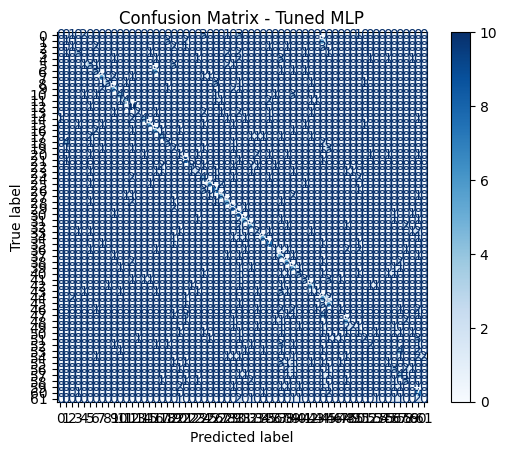

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Tuned MLP")
plt.show()

**Training loss vs epochs curve**

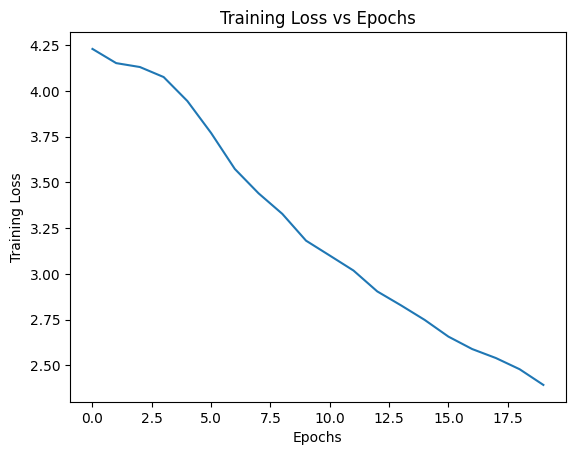

In [12]:

loss_values = best_model.loss_curve_

plt.plot(loss_values)
plt.xlabel("Epochs")
plt.ylabel("Training Loss")
plt.title("Training Loss vs Epochs")
plt.show()